# Refined Stage 3C - horizon sweep (RQ2)

How far ahead can each signal be forecast at a fixed history length? Horizon is swept in
steps with the context held constant **within each cell**, which isolates the horizon effect
inside a granularity.

This notebook also supplies the correction for the confound in the original Stage 2, where
the horizon was 48 / 24 / 14 steps for native / hourly / daily — perfectly co-varying with
granularity. With the response curves from here, the granularity comparison can be read at
a matched horizon instead of the co-varying one.

> ### Why this notebook was rebuilt
>
> Same two defects as 3B: five windows per cell regardless of what five windows covered,
> and one model load per configuration. The window count now comes from `C.windows_for()`,
> which takes the larger of a statistical floor and a time floor, and everything is scored
> in a single pass.
>
> Note the asymmetry this exposes: at a **6-step** horizon, 1-minute wind needs 3,360
> windows to cover 14 days, while daily data needs 3. A fixed count cannot serve both, and
> pretending it does is what made the original horizon curves incomparable across
> granularities.

> **One load, not one load per configuration.** Every window for every configuration is
> built first, then scored in a single pass. `C.run()` holds one model in memory at a time
> and iterates the whole list, so this notebook loads three models in total. The earlier
> pattern -- `C.run()` inside the sweep loop -- reloaded all three on every iteration,
> which in 3H meant 144 load/free cycles to support 27 minutes of inference.

In [1]:
import sys, os, shutil, warnings, importlib
warnings.filterwarnings("ignore")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import refined_stage_common as C

# A kernel that imported an older refined_stage_common keeps serving it from cache, and
# the failure surfaces much later as a missing column. Reload, then verify.
importlib.reload(C)
REQUIRED = "2026.09.10-relmae"
assert getattr(C, "__version__", None) == REQUIRED, (
    f"stale refined_stage_common (got {getattr(C, '__version__', 'none')}, "
    f"need {REQUIRED}) -- restart the kernel and Run All")
assert "plan_windows" in getattr(C, "__features__", set()), (
    "refined_stage_common predates the window planner -- restart the kernel and Run All")

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
PALETTE = {"chronos": "#2563eb", "timesfm": "#059669", "moirai": "#d97706"}
print(f"common module {C.__version__} from {C.__file__}")

common module 2026.09.10-relmae from e:\Thesis\EnergyForcastModel\refined_stage_common.py


In [2]:
DATA = C.get_data()

MIN_CTX = C.min_context_for(("chronos", "timesfm", "moirai"))   # TimesFM patches in 32s

def archive(path, tag):
    """Keep the previous (5-window) result next to the new one instead of overwriting it.

    The comparison between the two is itself a methodological finding, so the old file is
    evidence, not clutter.
    """
    old = path.replace(".csv", f"_{tag}.csv")
    if os.path.exists(path) and not os.path.exists(old):
        shutil.copy2(path, old)
        print(f"archived previous result -> {old}")

def shortest_series(etype, gran):
    return min(len(v) for v in C.panel(DATA, etype, gran))

def cell_geometry(etype, gran, horizon, ctx_cap, min_windows, min_days, max_windows,
                  ladder=(20, 10, 5)):
    """Pick (context, n_windows) for one cell from the series length it actually has.

    Context is taken as large as the cap allows while still leaving room for `min_windows`
    of targets. A 365-point daily solar series cannot reserve 30 x 24 target steps AND hold
    a usable context, so the window requirement steps down a ladder until something fits --
    and the rung it settles on is recorded, so the compromise appears in the table rather
    than being silently made.

    Returns None when no rung leaves a context the models can accept.
    """
    d = C.step_minutes(etype, gran)
    shortest = shortest_series(etype, gran)
    want = C.windows_for(etype, gran, horizon, min_windows, min_days, max_windows)
    c = k = None
    for rung in [min_windows] + [r for r in ladder if r < min_windows]:
        cc = min(int(ctx_cap), shortest - rung * int(horizon))
        if cc >= MIN_CTX:
            c, k = int(cc), int(rung)
            break
    if c is None:
        return None
    supply = (shortest - c) // int(horizon)
    n = int(min(want, supply))
    if n < 1:
        return None
    ev = n * int(horizon) * d
    return {"etype": etype, "gran": gran, "horizon_steps": int(horizon), "context": c,
            "window_floor_used": k, "wanted": int(want), "series_supports": int(supply),
            "n_windows": n, "evaluated_min": ev, "evaluated": C.human_duration(ev),
            "meets_floors": bool(n >= min_windows and ev >= min_days * 1440)}

def show_plan(rows, min_windows, min_days, cols=None):
    tab = pd.DataFrame(rows)
    cols = cols or ["etype", "gran", "context", "horizon_steps", "wanted",
                    "series_supports", "n_windows", "evaluated", "meets_floors"]
    print(tab[cols].to_string(index=False))
    bad = tab[~tab.meets_floors]
    if len(bad):
        print(f"\n{len(bad)} cell(s) cannot meet both floors (>= {min_windows} windows "
              f"AND >= {min_days} days). Report them as such -- do not quietly drop them:")
        print(bad[["etype", "gran", "n_windows", "evaluated"]].to_string(index=False))
    return tab

loaded cached panel <- refined_panel_cache.pkl
  load   5 series, 230,736–232,272 points
  solar  5 series, 52,560–52,560 points
  wind   5 series, 434,876–434,876 points


## 1. The plan

Context is held at the same value for every horizon within a cell, so the curves are
comparable along the horizon axis. Where the shortest series cannot hold that context plus
the reserved targets, the context is reduced for that cell and the reduction is printed —
the original Stage 2 shrank it silently, which is how the daily cells ended up running at
225–351 steps while the write-up said 512.

In [3]:
HOR_GRID   = [6, 12, 24, 48]
CTX_TARGET = 512      # the Stage 2 baseline; each cell's ceiling is per-cell and reported
MIN_WINDOWS, MIN_DAYS, MAX_WINDOWS = 30, 14.0, 90

# Context is held fixed per cell across horizons, so it must be chosen at the LARGEST
# horizon — that is the one reserving the most target steps. Choosing it at h=6 and then
# running h=48 would silently shrink it, which is the Stage 2 mistake.
CTX = {}
for et in C.BASE:
    for gk in C.GRANULARITIES:
        p = cell_geometry(et, gk, max(HOR_GRID), CTX_TARGET,
                          MIN_WINDOWS, MIN_DAYS, MAX_WINDOWS)
        if p is None:
            print(f"  {et}/{gk}: series too short for any usable context — excluded")
            continue
        CTX[(et, gk)] = p["context"]
        if p["context"] < CTX_TARGET:
            print(f"  {et}/{gk}: context {CTX_TARGET} -> {p['context']} steps "
                  f"(shortest series is {shortest_series(et, gk):,} points and must also "
                  f"reserve {p['window_floor_used']} x {max(HOR_GRID)} target steps)")

rows = []
for (et, gk), ctx in sorted(CTX.items()):
    d = C.step_minutes(et, gk)
    shortest = shortest_series(et, gk)
    for h in HOR_GRID:
        want = C.windows_for(et, gk, h, MIN_WINDOWS, MIN_DAYS, MAX_WINDOWS)
        supply = (shortest - ctx) // h
        n = int(min(want, supply))
        if n < 1:
            print(f"  {et}/{gk} h={h}: no window fits at context {ctx} — skipped"); continue
        ev = n * h * d
        rows.append({"etype": et, "gran": gk, "context": ctx, "horizon_steps": h,
                     "wanted": int(want), "series_supports": int(supply), "n_windows": n,
                     "evaluated_min": ev, "evaluated": C.human_duration(ev),
                     "lead": C.human_duration(h * d),
                     "meets_floors": bool(n >= MIN_WINDOWS and ev >= MIN_DAYS * 1440)})
PLAN = show_plan(rows, MIN_WINDOWS, MIN_DAYS,
                 cols=["etype", "gran", "context", "horizon_steps", "lead", "wanted",
                       "series_supports", "n_windows", "evaluated", "meets_floors"])

  solar/1D: context 512 -> 125 steps (shortest series is 365 points and must also reserve 5 x 48 target steps)
  wind/1D: context 512 -> 62 steps (shortest series is 302 points and must also reserve 5 x 48 target steps)
etype   gran  context  horizon_steps   lead  wanted  series_supports  n_windows evaluated  meets_floors
 load     1D      512              6  6.0 d      30              715         30   180.0 d          True
 load     1D      512             12 12.0 d      30              357         30   360.0 d          True
 load     1D      512             24 24.0 d      30              178         30   720.0 d          True
 load     1D      512             48 48.0 d      30               89         30  1440.0 d          True
 load     1h      512              6  6.0 h      56            19142         56    14.0 d          True
 load     1h      512             12 12.0 h      30             9571         30    15.0 d          True
 load     1h      512             24  1.0 d      30 

## 2. Build every window, then score once

In [4]:
archive("refined_stage3c_horizon_sweep.csv", "5window")

ALL = []
for r in PLAN.itertuples():
    if r.context < MIN_CTX:
        print(f"  {r.etype}/{r.gran}: context {r.context} < model floor {MIN_CTX} — skipped")
        continue
    W = C.build_windows(DATA, context_steps=r.context, horizon_steps=r.horizon_steps,
                        n_windows=r.n_windows, etypes=[r.etype], granularities=[r.gran],
                        verbose=False)
    ALL.extend(W)
    print(f"  {r.etype:6s}/{r.gran:7s} h={r.horizon_steps:>2} ctx={r.context:>4} "
          f"x {r.n_windows} windows ({r.evaluated} evaluated)")

ALL.sort(key=lambda w: (w.context_steps, w.horizon_steps))   # keeps Moirai's cache warm
pairs = len({(w.context_steps, w.horizon_steps) for w in ALL})
print(f"\n{len(ALL):,} windows across {pairs} (context, horizon) pairs "
      f"-> {len(ALL)*3:,} forecasts, 3 model loads.")
print(f"   the old pattern would have loaded {pairs*3} times for the same work.")
print(f"   rough estimate at 0.05-0.15 s per forecast: "
      f"{len(ALL)*3*0.05/60:.0f}-{len(ALL)*3*0.15/60:.0f} min")

MODELS = C.make_models(("chronos", "timesfm", "moirai"))
MODELS["moirai"].max_cached = 48    # one forecaster per (horizon, context); they share the
                                    # loaded module, so caching them costs almost no memory

sweep = C.run(MODELS, ALL)
C.save(sweep, "refined_stage3c_horizon_sweep.csv")

archived previous result -> refined_stage3c_horizon_sweep_5window.csv
  load  /1D      h= 6 ctx= 512 x 30 windows (180.0 d evaluated)
  load  /1D      h=12 ctx= 512 x 30 windows (360.0 d evaluated)
  load  /1D      h=24 ctx= 512 x 30 windows (720.0 d evaluated)
  load  /1D      h=48 ctx= 512 x 30 windows (1440.0 d evaluated)
  load  /1h      h= 6 ctx= 512 x 56 windows (14.0 d evaluated)
  load  /1h      h=12 ctx= 512 x 30 windows (15.0 d evaluated)
  load  /1h      h=24 ctx= 512 x 30 windows (30.0 d evaluated)
  load  /1h      h=48 ctx= 512 x 30 windows (60.0 d evaluated)
  load  /native  h= 6 ctx= 512 x 90 windows (11.2 d evaluated)
  load  /native  h=12 ctx= 512 x 56 windows (14.0 d evaluated)
  load  /native  h=24 ctx= 512 x 30 windows (15.0 d evaluated)
  load  /native  h=48 ctx= 512 x 30 windows (30.0 d evaluated)
  solar /1D      h= 6 ctx= 125 x 30 windows (180.0 d evaluated)
  solar /1D      h=12 ctx= 125 x 20 windows (240.0 d evaluated)
  solar /1D      h=24 ctx= 125 x 10 windo

chronos: 100%|██████████| 7800/7800 [07:46<00:00, 16.71it/s] 


  chronos: 7800/7800 scored | 0.10 GB -> freeing
loading timesfm (max_context=512, max_horizon=48) ...
    timesfm API = 2p5  (max_context=512, max_horizon=48)


timesfm: 100%|██████████| 7800/7800 [48:15<00:00,  2.69it/s]     


  timesfm: 7800/7800 scored | 0.93 GB -> freeing
loading moirai (max_context=512, max_horizon=48) ...


moirai: 100%|██████████| 7800/7800 [03:22<00:00, 38.54it/s]


  moirai: 7800/7800 scored | 0.06 GB -> freeing

NaN rate per model:
  chronos    0.0%
  moirai     0.0%
  timesfm    0.0%

All windows scored.
23,400 rows -> refined_stage3c_horizon_sweep.csv  (5.45 MB)


'refined_stage3c_horizon_sweep.csv'

## 3. The response curves

In [5]:
cl = C.clean(sweep)
curve = (cl.groupby(["etype", "gran_label", "model", "horizon_steps"])["relMAE"]
           .median().reset_index())
print(curve.pivot_table(index=["etype", "gran_label", "model"],
                        columns="horizon_steps", values="relMAE").round(3).to_string())

18,162/23,400 windows used | 5238 degenerate excluded
horizon_steps                      6      12     24     48
etype gran_label       model                              
load  daily            chronos  0.793  0.847  0.775  0.738
                       moirai   0.942  1.040  0.950  0.986
                       timesfm  0.564  0.573  0.471  0.414
      hourly           chronos  0.479  0.602  0.708  0.721
                       moirai   0.773  0.850  1.041  0.911
                       timesfm  0.501  0.629  0.850  0.853
      minutes (native) chronos  0.469  0.605  0.786  0.959
                       moirai   1.116  1.466  1.506  1.223
                       timesfm  0.335  0.439  0.556  0.728
solar daily            chronos  0.743  0.802  0.809  0.799
                       moirai   0.749  0.818  0.841  0.837
                       timesfm  0.730  0.752  0.784  0.738
      hourly           chronos  0.858  0.886  0.937  0.874
                       moirai   0.934  1.033  1.156  1.043
  

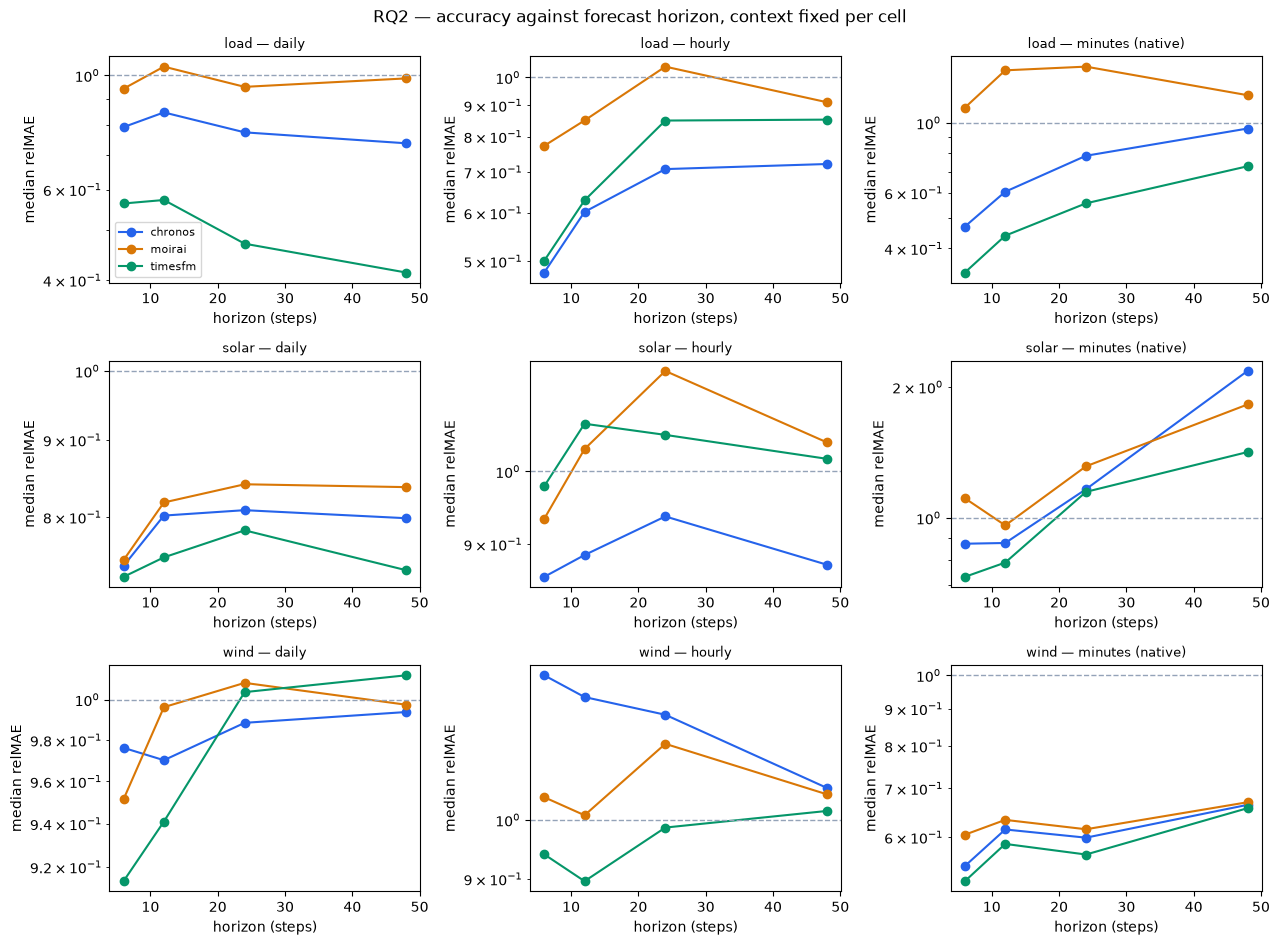

In [6]:
cells = curve.groupby(["etype", "gran_label"]).size().index.tolist()
n = len(cells); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.3*ncol, 3.2*nrow), squeeze=False)
for ax, (et, gl) in zip(axes.ravel(), cells):
    sub = curve[(curve.etype == et) & (curve.gran_label == gl)]
    for mdl, g in sub.groupby("model"):
        ax.plot(g.horizon_steps, g.relMAE, marker="o", label=mdl, color=PALETTE.get(mdl))
    ax.axhline(1.0, color="#94a3b8", ls="--", lw=1)
    ax.set_yscale("log"); ax.set_title(f"{et} — {gl}", fontsize=9)
    ax.set_xlabel("horizon (steps)"); ax.set_ylabel("median relMAE")
for ax in axes.ravel()[n:]:
    ax.axis("off")
axes[0][0].legend(fontsize=8)
plt.suptitle("RQ2 — accuracy against forecast horizon, context fixed per cell")
plt.tight_layout(); plt.show()

## 4. The same curves in duration units

RQ2 asks for both step counts and real-world lead time. A 48-step horizon is 48 minutes of
wind and 48 days of daily data; only the right-hand table is meaningful to an operator.

In [7]:
t = (cl.groupby(["etype", "gran_label", "horizon_steps"])
       .agg(lead=("lead_minutes", "first"), history=("history_minutes", "first"),
            relMAE=("relMAE", "median"), n=("relMAE", "size")).reset_index())
t["lead"] = t.lead.map(C.human_duration)
t["history"] = t.history.map(C.human_duration)
print(t.round(3).to_string(index=False))

etype       gran_label  horizon_steps   lead history  relMAE    n
 load            daily              6  6.0 d 512.0 d   0.760  450
 load            daily             12 12.0 d 512.0 d   0.812  450
 load            daily             24 24.0 d 512.0 d   0.720  450
 load            daily             48 48.0 d 512.0 d   0.683  450
 load           hourly              6  6.0 h  21.3 d   0.562  840
 load           hourly             12 12.0 h  21.3 d   0.654  450
 load           hourly             24  1.0 d  21.3 d   0.887  450
 load           hourly             48  2.0 d  21.3 d   0.818  450
 load minutes (native)              6  3.0 h  10.7 d   0.534 1350
 load minutes (native)             12  6.0 h  10.7 d   0.716  840
 load minutes (native)             24 12.0 h  10.7 d   0.858  450
 load minutes (native)             48  1.0 d  10.7 d   0.969  450
solar            daily              6  6.0 d 125.0 d   0.740  450
solar            daily             12 12.0 d 125.0 d   0.798  300
solar     

## 5. The history-to-horizon ratio

If a rule of thumb exists — *keep at least k steps of history per step of horizon* — it
shows up here as a curve that collapses across energy types. If the types stay separated,
there is no universal ratio and the recommendation has to be per-signal, which is itself a
useful answer for RQ3.

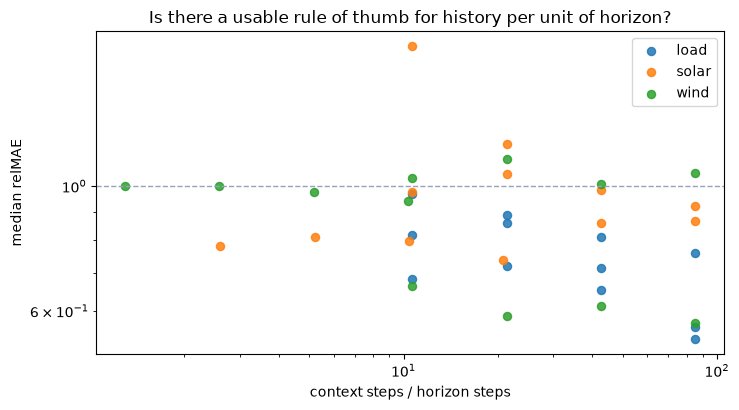

Spearman(history/horizon, relMAE) — negative means more history per step helps:
  load   rho=-0.605  p=0.0373  (n=12)
  solar  rho=+0.338  p=0.2825  (n=12)
  wind   rho=-0.092  p=0.7772  (n=12)


In [8]:
cl = cl.copy()
cl["hist_per_horizon"] = cl["context_steps"] / cl["horizon_steps"]
r = (cl.groupby(["etype", "gran", "hist_per_horizon"])["relMAE"].median()
       .reset_index().sort_values("hist_per_horizon"))
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for et, g in r.groupby("etype"):
    ax.scatter(g.hist_per_horizon, g.relMAE, label=et, s=34, alpha=0.85)
ax.axhline(1.0, color="#94a3b8", ls="--", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("context steps / horizon steps"); ax.set_ylabel("median relMAE")
ax.set_title("Is there a usable rule of thumb for history per unit of horizon?")
ax.legend(); plt.tight_layout(); plt.show()

from scipy.stats import spearmanr
print("Spearman(history/horizon, relMAE) — negative means more history per step helps:")
for et, g in r.groupby("etype"):
    g = g.dropna(subset=["relMAE"])
    if len(g) > 3:
        rho, p = spearmanr(g.hist_per_horizon, g.relMAE)
        print(f"  {et:6s} rho={rho:+.3f}  p={p:.4f}  (n={len(g)})")

Re-run `refined_stage3e_significance` and `refined_stage3f_selection_matrix` after this
notebook — both read `refined_stage3c_horizon_sweep.csv`.

Next: `refined_stage3d_fixed_lead_time` — the de-confounded granularity test.